In [7]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import numpy as np
from sklearn.model_selection import train_test_split 
from torchmetrics.classification import MulticlassAccuracy
from sklearn.preprocessing import LabelEncoder

In [8]:
df= pd.read_csv("dataset/09-iris.csv")

In [9]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

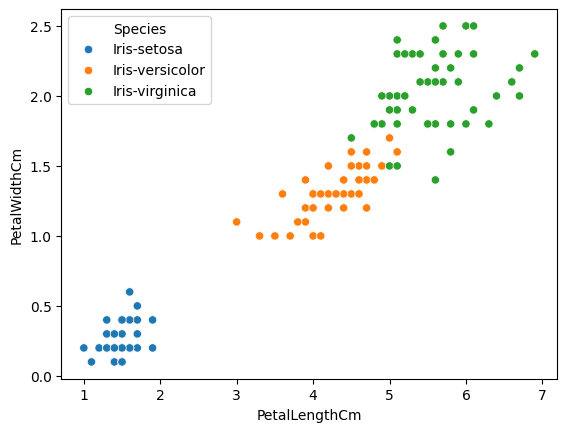

In [10]:
sns.scatterplot(x=df["PetalLengthCm"], y=df["PetalWidthCm"], hue= df["Species"])
plt.show()

In [11]:
df= df.drop("Id", axis=1)

In [12]:
X= df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm","PetalWidthCm"]].values
y= df["Species"].values

In [13]:
le= LabelEncoder() 
y= le.fit_transform(y)

In [14]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
X_train= torch.tensor(X_train, dtype= torch.float32)
X_test= torch.tensor(X_test, dtype= torch.float32)

y_train= torch.tensor(y_train, dtype= torch.long)
y_test= torch.tensor(y_test, dtype= torch.long)

In [16]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

torch.Size([120, 4]) torch.Size([30, 4]) torch.Size([120]) torch.Size([30])


In [23]:
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer_1 = nn.Linear(in_features = 4, out_features = 16)
        self.layer_2 = nn.Linear(in_features = 16, out_features = 16)
        self.layer_3 = nn.Linear(in_features = 16, out_features = 3)
        self.relu = nn.ReLU()

    def forward(self,x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

In [24]:
model = IrisClassifier()

In [25]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.01)

In [26]:
accuracy = MulticlassAccuracy(num_classes=3) # Kaç tane sınıf varsa num_classes ona eşit olmalı

In [27]:
epochs = 200

for epoch in range(epochs):
    ### TRAIN ###
    model.train()
    logits = model(X_train)
    loss = loss_fn(logits, y_train)

    pred = torch.argmax(logits, dim=1) 
    acc = accuracy(pred, y_train).item() * 100 # item kullanma sebebimiz tensor olarak veriliyor oradan çıkarmak 

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)
        test_pred = torch.argmax(test_logits, dim=1)
        test_acc = accuracy(test_pred, y_test).item() * 100

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")
        

Epoch 0 | Loss: 1.2404 | Acc: 33.33% | Test Loss: 1.1706 | Test Acc: 33.33%
Epoch 20 | Loss: 0.5782 | Acc: 70.00% | Test Loss: 0.5464 | Test Acc: 73.33%
Epoch 40 | Loss: 0.1447 | Acc: 98.33% | Test Loss: 0.1430 | Test Acc: 96.67%
Epoch 60 | Loss: 0.0667 | Acc: 97.50% | Test Loss: 0.0496 | Test Acc: 100.00%
Epoch 80 | Loss: 0.0589 | Acc: 97.50% | Test Loss: 0.0389 | Test Acc: 100.00%
Epoch 100 | Loss: 0.0556 | Acc: 98.33% | Test Loss: 0.0356 | Test Acc: 100.00%
Epoch 120 | Loss: 0.0527 | Acc: 98.33% | Test Loss: 0.0404 | Test Acc: 100.00%
Epoch 140 | Loss: 0.0506 | Acc: 98.33% | Test Loss: 0.0419 | Test Acc: 100.00%
Epoch 160 | Loss: 0.0489 | Acc: 98.33% | Test Loss: 0.0441 | Test Acc: 100.00%
Epoch 180 | Loss: 0.0475 | Acc: 98.33% | Test Loss: 0.0505 | Test Acc: 96.67%
